# 🧠 WellSense — Student Mental Health Prediction
### University ML Assessment Project

**Project:** WellSense  
**Objective:** Predict depression risk in students using classical ML models  
**Dataset:** Student Depression Dataset — adilshamim8 (Kaggle)  
**Context:** India-relevant dataset (Indian cities, CGPA 0–10 scale, Indian degrees)  
**Models:** Logistic Regression, Decision Tree, Random Forest, SVM, k-NN, Naive Bayes, MLP  

---

## 📦 Phase 1 — Setup & Imports

In [78]:
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

os.makedirs('../models', exist_ok=True)
os.makedirs('../assets', exist_ok=True)
print('✅ All libraries imported!')

✅ All libraries imported!


---
## 📂 Phase 1 — Load Dataset
> **Download:** https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset  
> Save as `student_depression.csv` inside the `data/` folder.

In [79]:
df = pd.read_csv('data/student_depression_dataset.csv')
print(f'✅ Dataset loaded! Shape: {df.shape}')
df.head()

✅ Dataset loaded! Shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [80]:
print('Columns:', df.columns.tolist())
print('\nTarget distribution:')
print(df['Depression'].value_counts())
df.describe(include='all')

Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']

Target distribution:
Depression
1    16336
0    11565
Name: count, dtype: int64


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27901.000000,27901,27901.000000,27901,27901,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901,27901,27901,27901,27901.000000,27901,27901,27901.000000
unique,NaN,2,NaN,52,14,NaN,NaN,NaN,NaN,NaN,5,4,28,2,NaN,6,2,NaN
top,NaN,Male,NaN,Kalyan,Student,NaN,NaN,NaN,NaN,NaN,'Less than 5 hours',Unhealthy,'Class 12',Yes,NaN,5.0,No,NaN
freq,NaN,15547,NaN,1570,27870,NaN,NaN,NaN,NaN,NaN,8310,10317,6080,17656,NaN,6715,14398,NaN
mean,70442.149421,NaN,25.822300,NaN,NaN,3.141214,0.000430,7.656104,2.943837,0.000681,NaN,NaN,NaN,NaN,7.156984,NaN,NaN,0.585499
std,40641.175216,NaN,4.905687,NaN,NaN,1.381465,0.043992,1.470707,1.361148,0.044394,NaN,NaN,NaN,NaN,3.707642,NaN,NaN,0.492645
min,2.000000,NaN,18.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000
25%,35039.000000,NaN,21.000000,NaN,NaN,2.000000,0.000000,6.290000,2.000000,0.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,0.000000
50%,70684.000000,NaN,25.000000,NaN,NaN,3.000000,0.000000,7.770000,3.000000,0.000000,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,1.000000
75%,105818.000000,NaN,30.000000,NaN,NaN,4.000000,0.000000,8.920000,4.000000,0.000000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,1.000000


---
## 🔍 Phase 1 — Exploratory Data Analysis (EDA)

In [81]:
# Missing values
missing = df.isnull().sum()
missing_df = pd.DataFrame({'Missing': missing, 'Pct': (missing/len(df))*100})
missing_df = missing_df[missing_df['Missing'] > 0]
print('✅ No missing values!' if missing_df.empty else missing_df)

✅ No missing values!


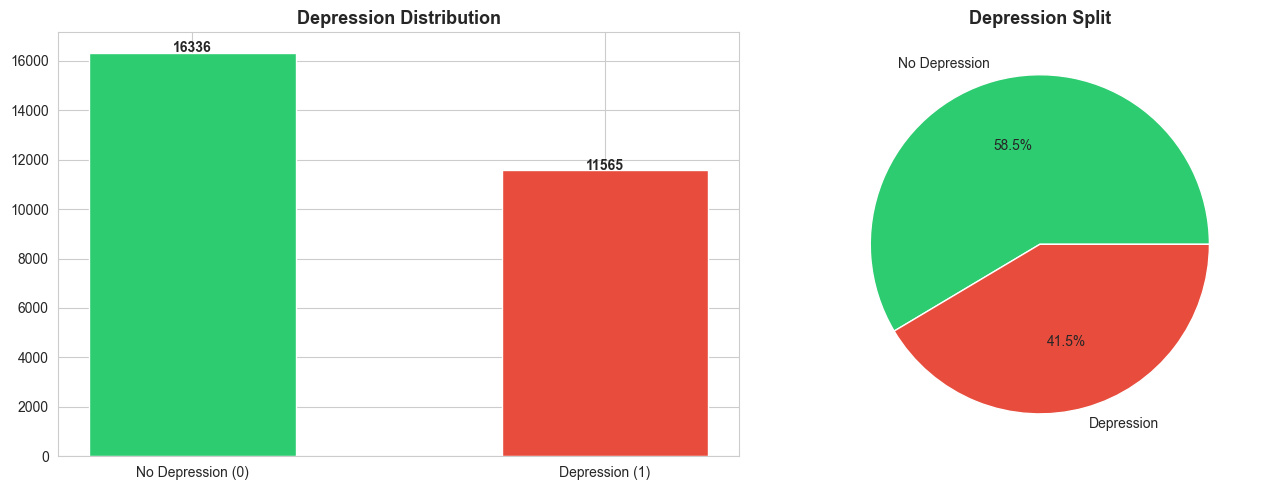

In [82]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['Depression'].value_counts()
axes[0].bar(['No Depression (0)', 'Depression (1)'], counts.values, color=['#2ecc71','#e74c3c'], width=0.5)
axes[0].set_title('Depression Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(counts.values): axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['No Depression','Depression'], colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%')
axes[1].set_title('Depression Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

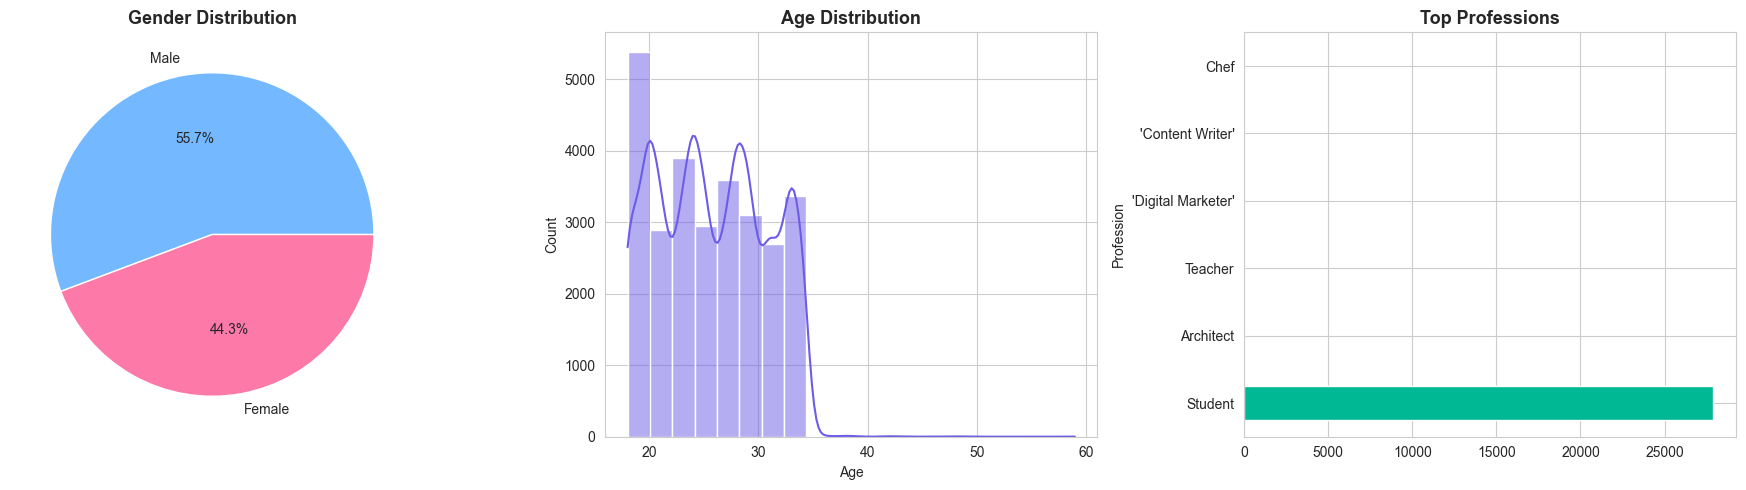

In [83]:
# Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df['Gender'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['#74b9ff','#fd79a8'])
axes[0].set_title('Gender Distribution', fontsize=13, fontweight='bold'); axes[0].set_ylabel('')
sns.histplot(df['Age'].dropna(), bins=20, kde=True, ax=axes[1], color='#6c5ce7')
axes[1].set_title('Age Distribution', fontsize=13, fontweight='bold')
df['Profession'].value_counts().head(6).plot(kind='barh', ax=axes[2], color='#00b894')
axes[2].set_title('Top Professions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/demographics.png', dpi=150, bbox_inches='tight')
plt.show()

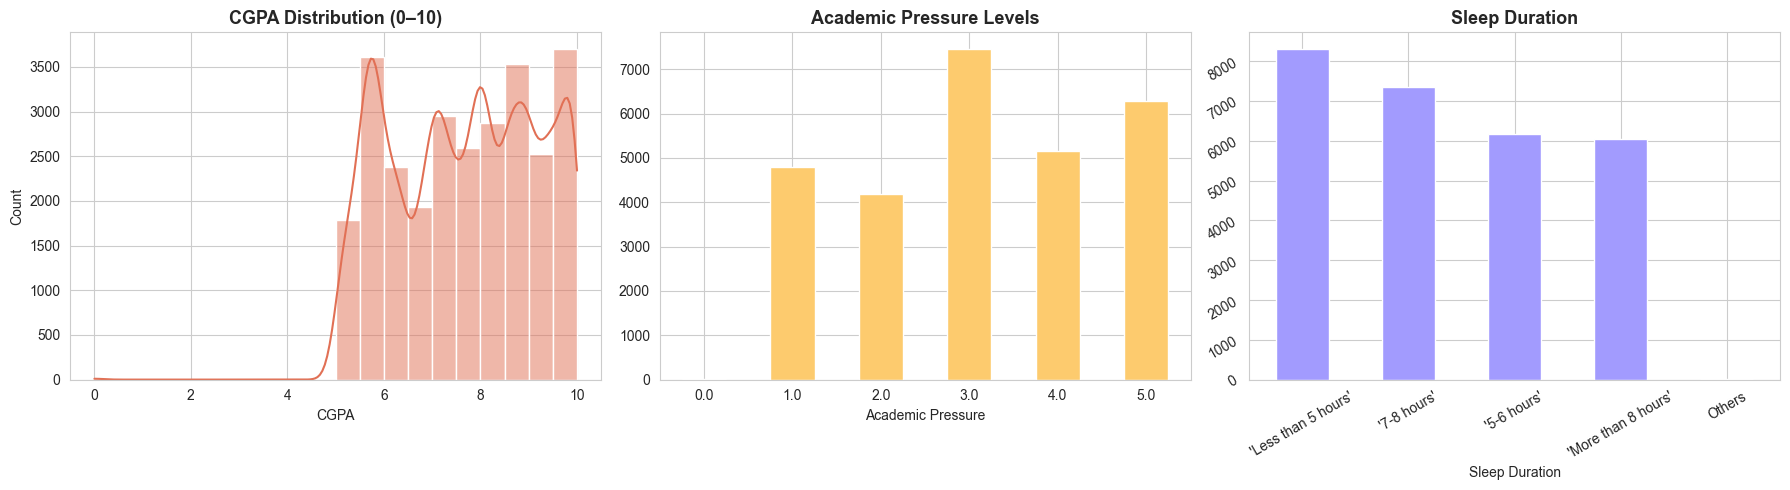

In [84]:
# Academic features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['CGPA'].dropna(), bins=20, kde=True, ax=axes[0], color='#e17055')
axes[0].set_title('CGPA Distribution (0–10)', fontsize=13, fontweight='bold')
df['Academic Pressure'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#fdcb6e')
axes[1].set_title('Academic Pressure Levels', fontsize=13, fontweight='bold'); axes[1].tick_params(rotation=0)
df['Sleep Duration'].value_counts().plot(kind='bar', ax=axes[2], color='#a29bfe')
axes[2].set_title('Sleep Duration', fontsize=13, fontweight='bold'); axes[2].tick_params(rotation=30)
plt.tight_layout()
plt.savefig('../assets/academic_features.png', dpi=150, bbox_inches='tight')
plt.show()

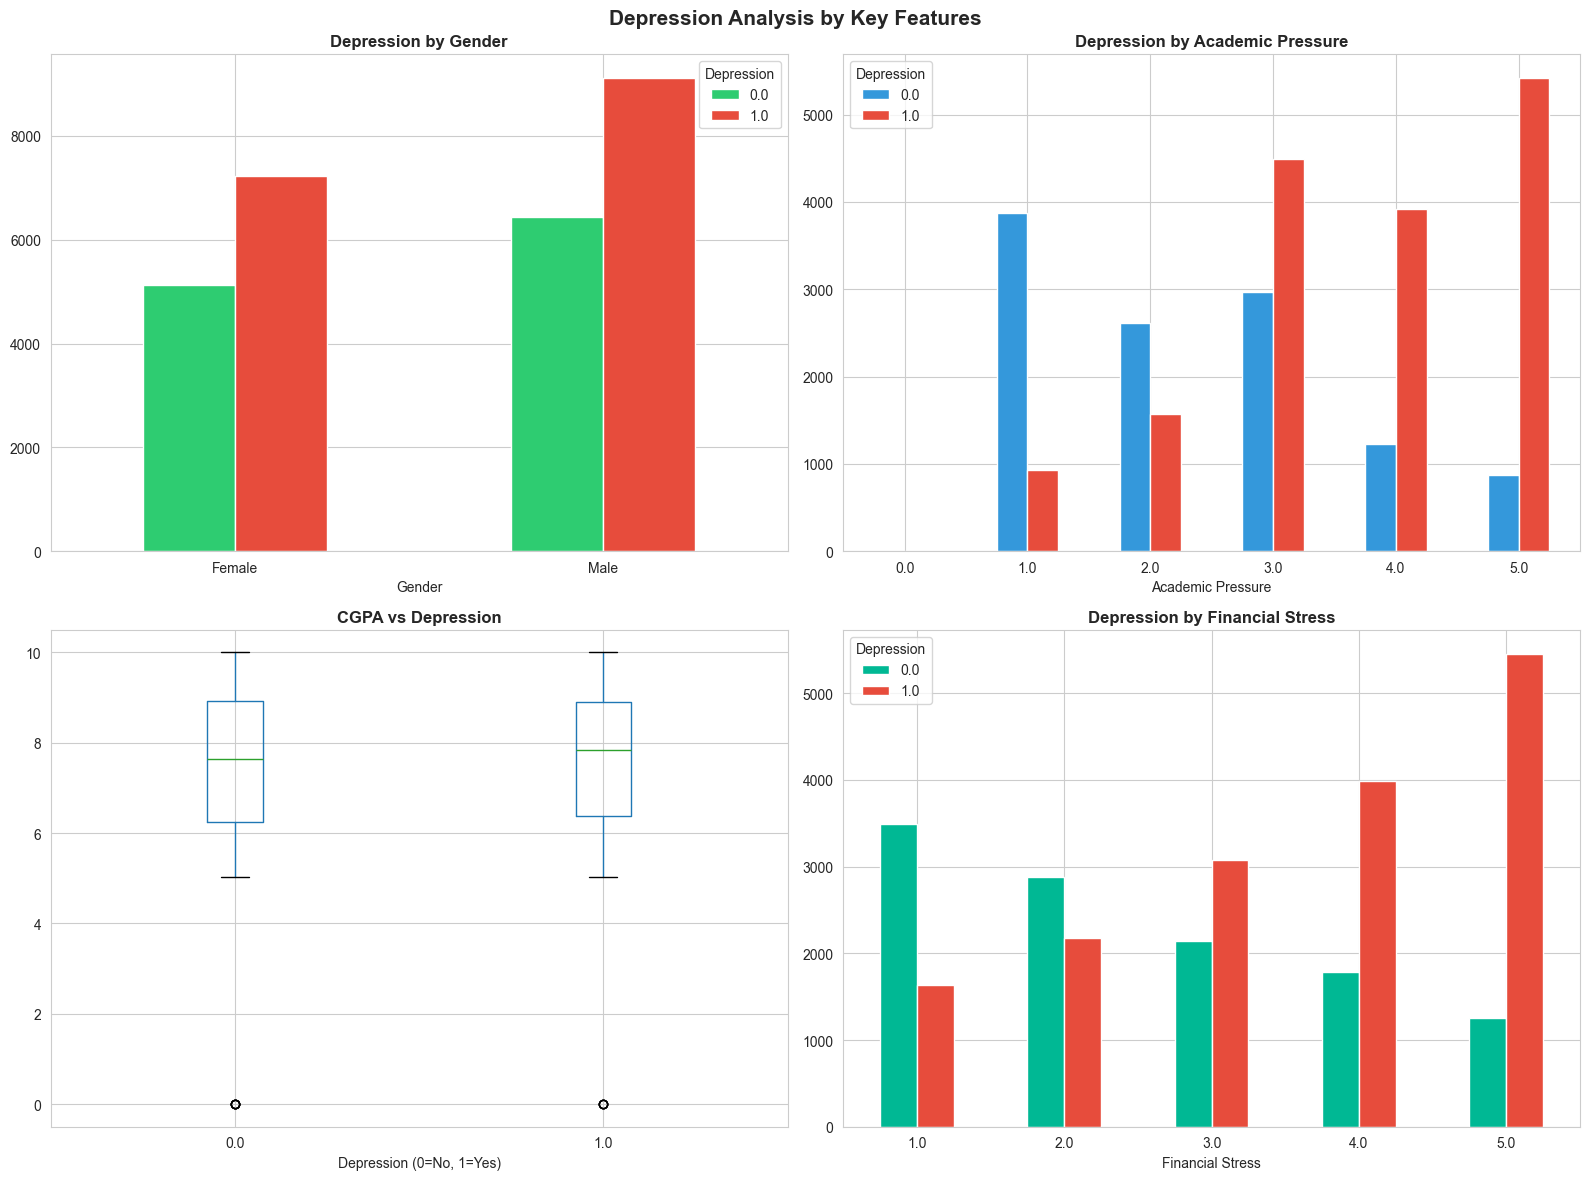

In [85]:
# Handle missing values represented as '?'
df.replace('?', np.nan, inplace=True)
# Convert numeric columns to float
num_cols = ['Age','Academic Pressure','Work Pressure','CGPA','Study Satisfaction',
            'Job Satisfaction','Work/Study Hours','Financial Stress','Depression']
df[num_cols] = df[num_cols].astype(float)


# Depression by key features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
pd.crosstab(df['Gender'], df['Depression']).plot(kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Depression by Gender', fontsize=12, fontweight='bold'); axes[0,0].tick_params(rotation=0)
pd.crosstab(df['Academic Pressure'], df['Depression']).plot(kind='bar', ax=axes[0,1], color=['#3498db','#e74c3c'])
axes[0,1].set_title('Depression by Academic Pressure', fontsize=12, fontweight='bold'); axes[0,1].tick_params(rotation=0)
df.boxplot(column='CGPA', by='Depression', ax=axes[1,0])
axes[1,0].set_title('CGPA vs Depression', fontsize=12, fontweight='bold'); axes[1,0].set_xlabel('Depression (0=No, 1=Yes)')
pd.crosstab(df['Financial Stress'], df['Depression']).plot(kind='bar', ax=axes[1,1], color=['#00b894','#e74c3c'])
axes[1,1].set_title('Depression by Financial Stress', fontsize=12, fontweight='bold'); axes[1,1].tick_params(rotation=0)
plt.suptitle('Depression Analysis by Key Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/depression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

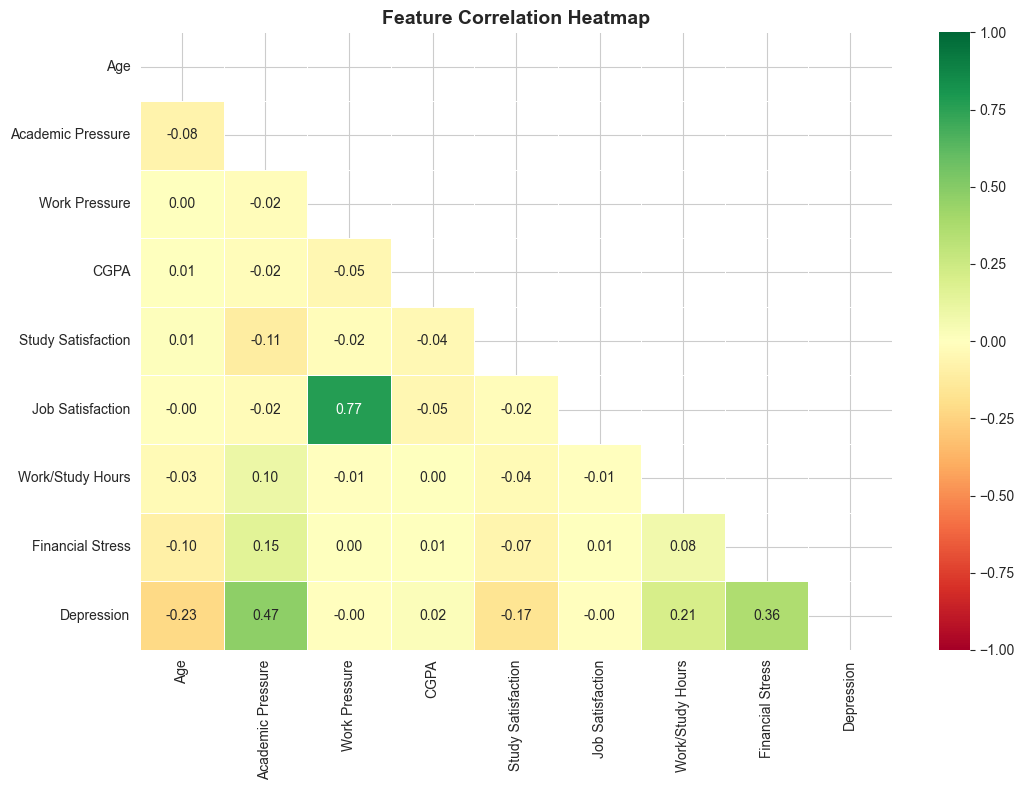

In [86]:

# Correlation heatmap
num_cols = ['Age','Academic Pressure','Work Pressure','CGPA','Study Satisfaction',
            'Job Satisfaction','Work/Study Hours','Financial Stress','Depression']
plt.figure(figsize=(11, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ Phase 2 — Preprocessing

In [87]:
# Drop irrelevant columns
df_clean = df.drop(columns=['id', 'City', 'Job Satisfaction'])
print(f'Remaining columns: {df_clean.columns.tolist()}')

Remaining columns: ['Gender', 'Age', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


In [88]:
# Handle missing values
df_clean = df_clean.dropna(axis=1, how='all')
df_clean.fillna(df_clean.median(numeric_only=True), inplace=True)
df_clean.fillna('Unknown', inplace=True)
print('✅ Missing values handled! Remaining:', df_clean.isnull().sum().sum())

✅ Missing values handled! Remaining: 0


In [89]:
# Label Encoding
categorical_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Encoding: {categorical_cols}')
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print('✅ Encoding complete!')

Encoding: ['Gender', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Profession: {"'Civil Engineer'": np.int64(0), "'Content Writer'": np.int64(1), "'Digital Marketer'": np.int64(2), "'Educational Consultant'": np.int64(3), "'UX/UI Designer'": np.int64(4), 'Architect': np.int64(5), 'Chef': np.int64(6), 'Doctor': np.int64(7), 'Entrepreneur': np.int64(8), 'Lawyer': np.int64(9), 'Manager': np.int64(10), 'Pharmacist': np.int64(11), 'Student': np.int64(12), 'Teacher': np.int64(13)}
  Sleep Duration: {"'5-6 hours'": np.int64(0), "'7-8 hours'": np.int64(1), "'Less than 5 hours'": np.int64(2), "'More than 8 hours'": np.int64(3), 'Others': np.int64(4)}
  Dietary Habits: {'Healthy': np.int64(0), 'Moderate': np.int64(1), 'Others': np.int64(2), 'Unhealthy': np.int64(3)}
  Degree: {"'Class 12'": np.int64(0), 'B.Arch': np.int64(1), 'B.Com': np.int64(2), 'B

In [90]:
# Feature / Target split
TARGET   = 'Depression'
FEATURES = [col for col in df_clean.columns if col != TARGET]
X = df_clean[FEATURES]
y = df_clean[TARGET]
print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Class balance: {dict(y.value_counts())}')

Features (14): ['Gender', 'Age', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness']
Class balance: {1.0: np.int64(16336), 0.0: np.int64(11565)}


In [91]:
# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_balanced, y_balanced = smote.fit_resample(X, y)
print(f'Before SMOTE: {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'After  SMOTE: {dict(zip(*np.unique(y_balanced, return_counts=True)))}')

Before SMOTE: {np.float64(0.0): np.int64(11565), np.float64(1.0): np.int64(16336)}
After  SMOTE: {np.float64(0.0): np.int64(16336), np.float64(1.0): np.int64(16336)}


In [92]:
# StandardScaler + Train/Test Split
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_balanced, test_size=0.2, random_state=RANDOM_STATE, stratify=y_balanced
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 26137 | Test: 6535


Original features: 14 → PCA components: 13
Variance retained: 95.97%


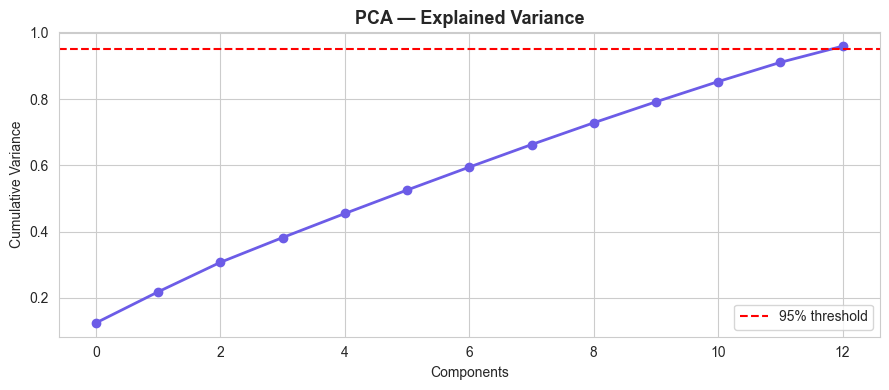

In [93]:
# PCA
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
pca.fit(X_train)
print(f'Original features: {X_train.shape[1]} → PCA components: {pca.n_components_}')
print(f'Variance retained: {sum(pca.explained_variance_ratio_):.2%}')
plt.figure(figsize=(9, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', color='#6c5ce7', lw=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Components'); plt.ylabel('Cumulative Variance')
plt.title('PCA — Explained Variance', fontsize=13, fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('../assets/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 Phase 3 — Model Building & Training

In [94]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM'                : SVC(probability=True, random_state=RANDOM_STATE),
    'k-NN'               : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'        : GaussianNB(),
    'MLP Neural Net'     : MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=RANDOM_STATE)
}
print(f'✅ {len(models)} models ready!')

✅ 7 models ready!


In [95]:
results = {}; trained_models = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model,'predict_proba') else None
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'F1 Score' : round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4) if y_proba is not None else 'N/A'
    }
    trained_models[name] = model
    print(f"Acc={results[name]['Accuracy']} ✅")
print('\n🎉 All models trained!')

Training Logistic Regression... Acc=0.8566 ✅
Training Decision Tree... Acc=0.7965 ✅
Training Random Forest... Acc=0.8627 ✅
Training SVM... Acc=0.8549 ✅
Training k-NN... Acc=0.8364 ✅
Training Naive Bayes... Acc=0.85 ✅
Training MLP Neural Net... Acc=0.8454 ✅

🎉 All models trained!


---
## 📊 Phase 4 — Evaluation

In [96]:
results_df = pd.DataFrame(results).T.sort_values('F1 Score', ascending=False)
results_df.index.name = 'Model'
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Random Forest,0.8627,0.8628,0.8627,0.8627,0.9370
Logistic Regression,0.8566,0.8567,0.8566,0.8566,0.9311
SVM,0.8549,0.8552,0.8549,0.8549,0.9240
Naive Bayes,0.8500,0.8514,0.8500,0.8499,0.9282
MLP Neural Net,0.8454,0.8454,0.8454,0.8454,0.9169
k-NN,0.8364,0.8364,0.8364,0.8364,0.9007
Decision Tree,0.7965,0.7965,0.7965,0.7965,0.7965


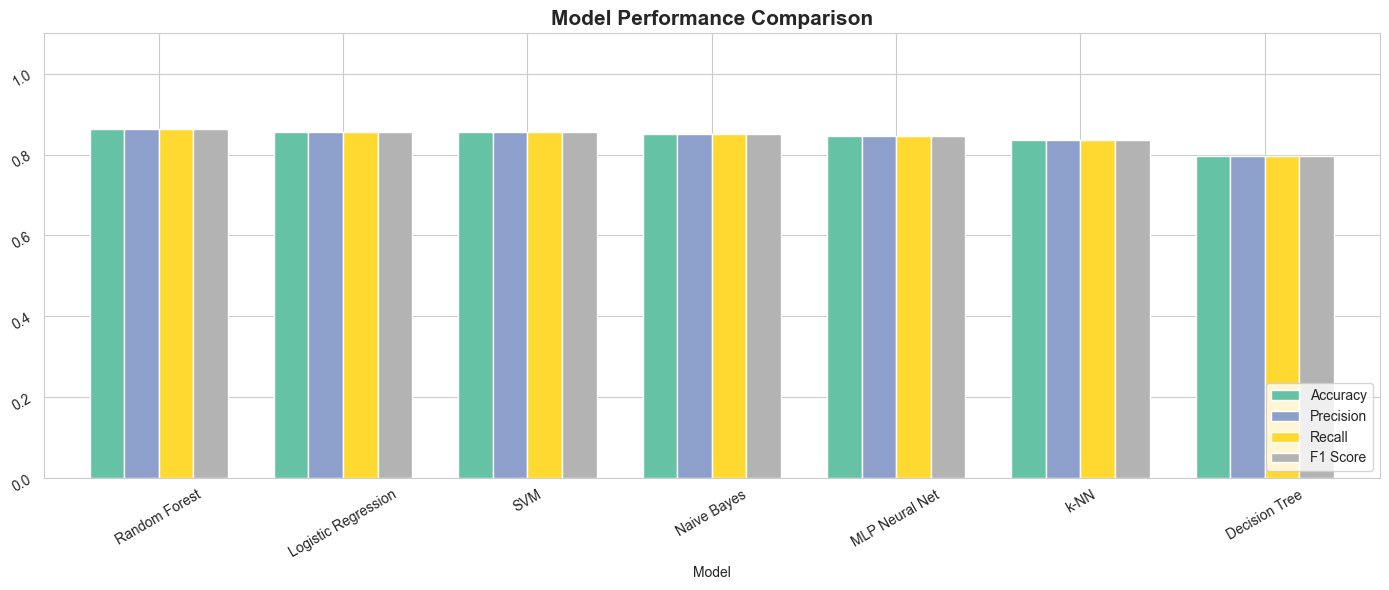

In [97]:
plot_df = results_df[['Accuracy','Precision','Recall','F1 Score']].astype(float)
ax = plot_df.plot(kind='bar', figsize=(14,6), width=0.75, colormap='Set2', edgecolor='white')
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_ylim(0, 1.1); ax.tick_params(rotation=30); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

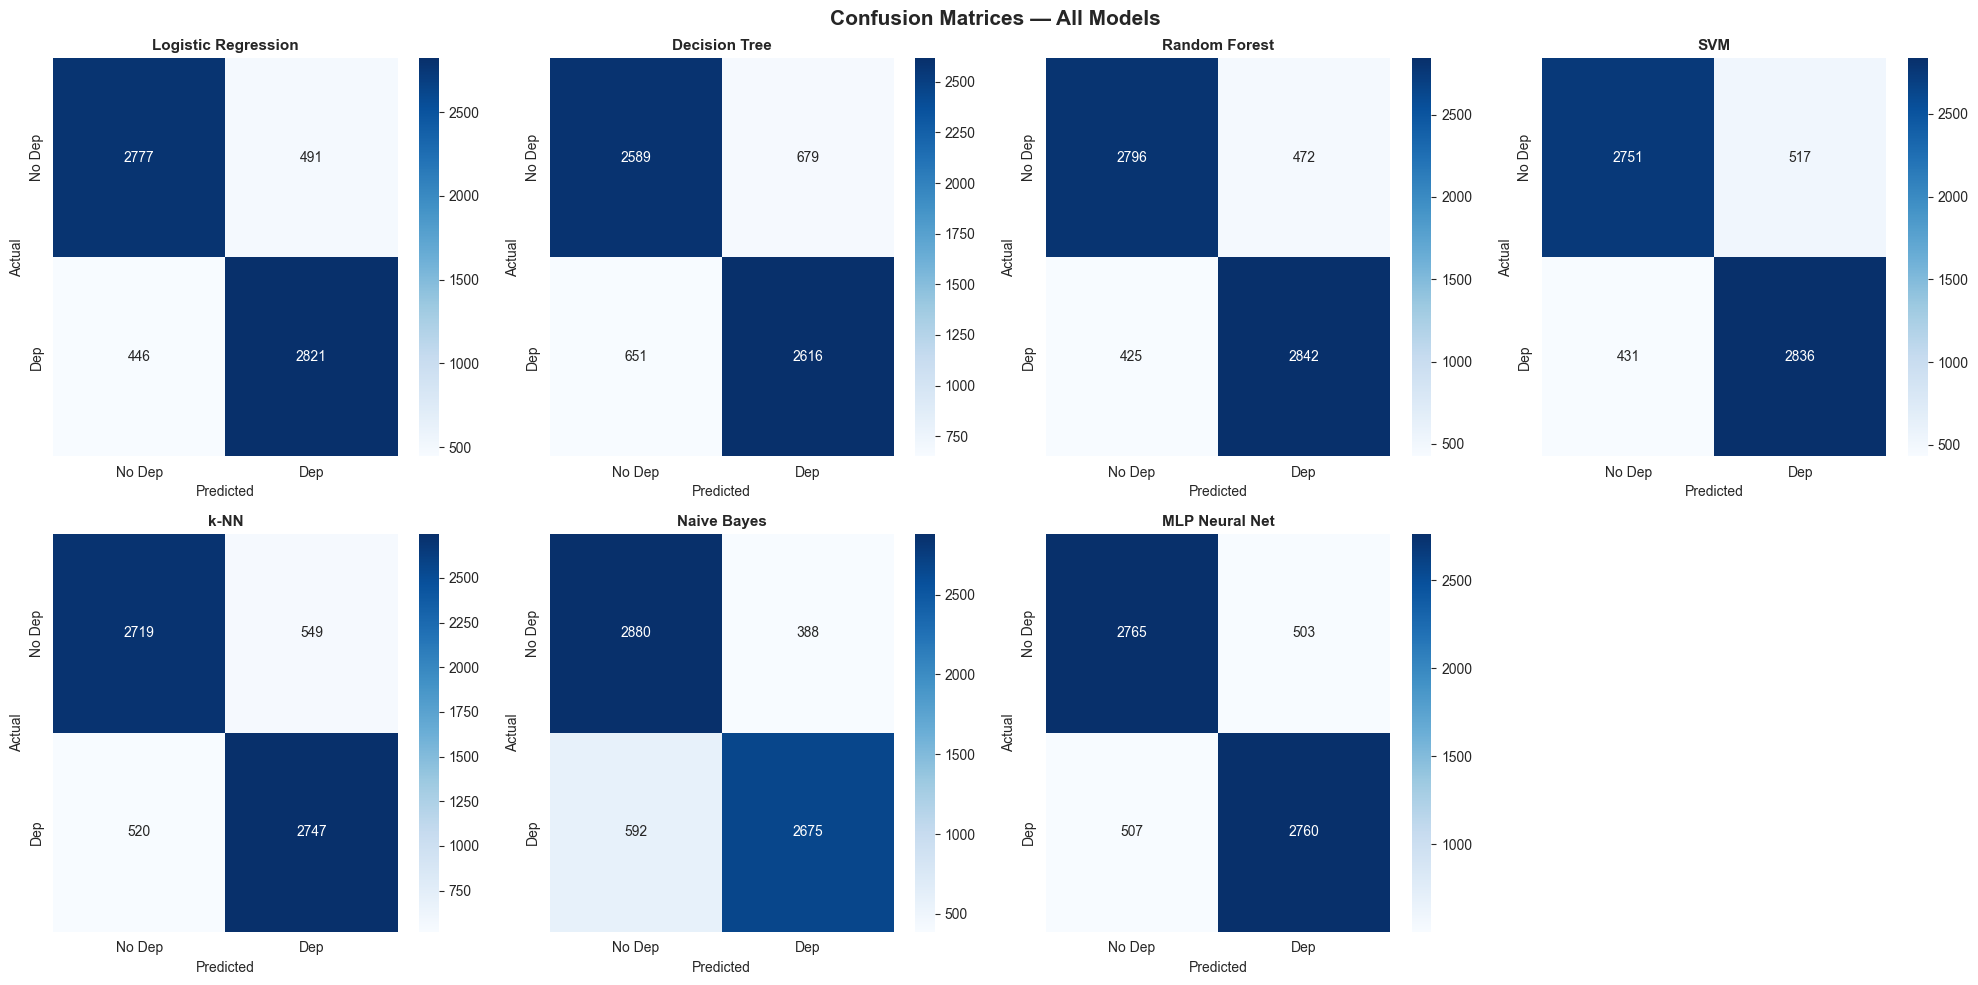

In [98]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10)); axes = axes.flatten()
for idx, (name, model) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Dep','Dep'], yticklabels=['No Dep','Dep'])
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
fig.delaxes(axes[-1])
plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

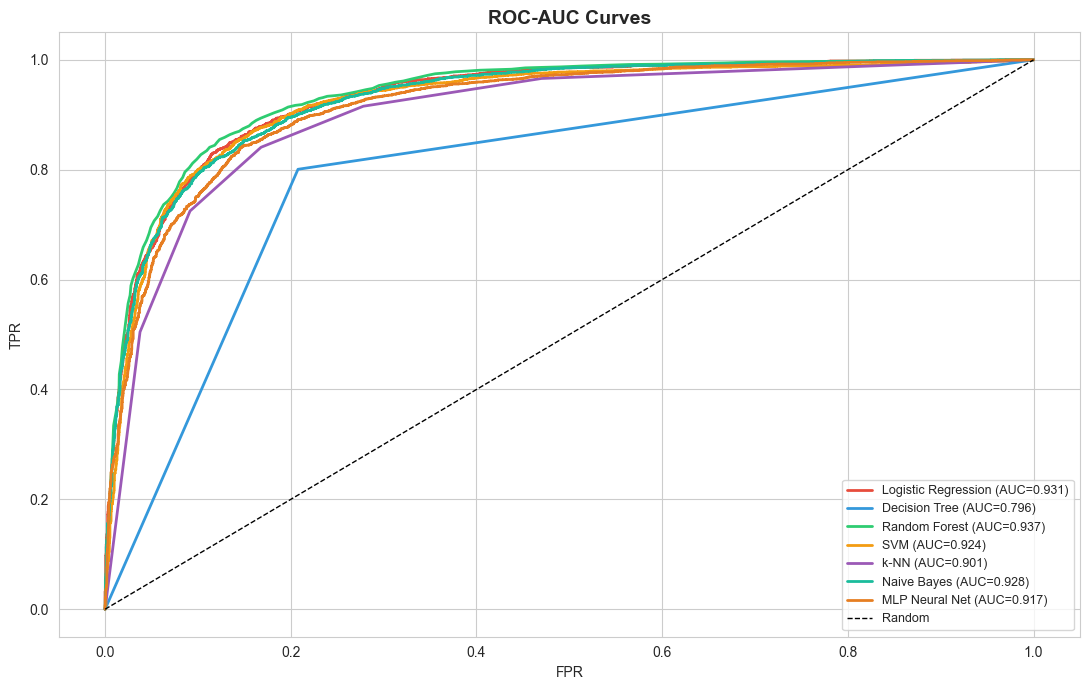

In [99]:
plt.figure(figsize=(11, 7))
colors_roc = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
for (name, model), color in zip(trained_models.items(), colors_roc):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test,y_proba):.3f})', color=color, lw=2)
plt.plot([0,1],[0,1],'k--', label='Random', lw=1)
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC-AUC Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9); plt.tight_layout()
plt.savefig('../assets/roc_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [100]:
best_name = results_df.index[0]
print(f'🏆 Best Model: {best_name}')
print(classification_report(y_test, trained_models[best_name].predict(X_test),
      target_names=['No Depression','Depression']))

🏆 Best Model: Random Forest
               precision    recall  f1-score   support

No Depression       0.87      0.86      0.86      3268
   Depression       0.86      0.87      0.86      3267

     accuracy                           0.86      6535
    macro avg       0.86      0.86      0.86      6535
 weighted avg       0.86      0.86      0.86      6535



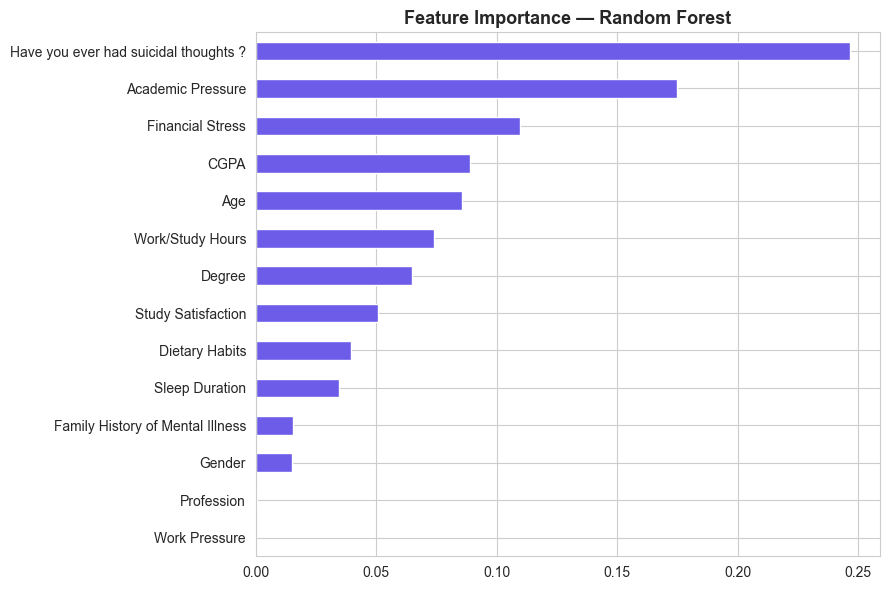

In [101]:
rf = trained_models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
plt.figure(figsize=(9,6))
importances.plot(kind='barh', color='#6c5ce7')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 Phase 5 — Optimization

In [102]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('5-Fold Cross Validation:\n')
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y_balanced, cv=kfold, scoring='f1_weighted')
    print(f'{name:25s} → F1: {scores.mean():.4f} ± {scores.std():.4f}')

5-Fold Cross Validation:

Logistic Regression       → F1: 0.8552 ± 0.0025
Decision Tree             → F1: 0.7966 ± 0.0040
Random Forest             → F1: 0.8641 ± 0.0025
SVM                       → F1: 0.8535 ± 0.0029
k-NN                      → F1: 0.8385 ± 0.0051
Naive Bayes               → F1: 0.7344 ± 0.2008
MLP Neural Net            → F1: 0.8384 ± 0.0056


In [103]:
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print(f'\n✅ Best Params : {grid_search.best_params_}')
print(f'✅ Best F1     : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best Params : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
✅ Best F1     : 0.8637


In [104]:
best_model_final = grid_search.best_estimator_
y_pred_tuned     = best_model_final.predict(X_test)
print('🏆 Tuned Random Forest:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'  F1 Score : {f1_score(y_test, y_pred_tuned, average="weighted"):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, best_model_final.predict_proba(X_test)[:,1]):.4f}')

🏆 Tuned Random Forest:
  Accuracy : 0.8626
  F1 Score : 0.8626
  ROC-AUC  : 0.9377


---
## 💾 Phase 6 — Save All Artifacts

In [105]:
joblib.dump(best_model_final, '../models/best_model.pkl')
joblib.dump(scaler,           '../models/scaler.pkl')
joblib.dump(label_encoders,   '../models/label_encoders.pkl')
joblib.dump(results_df,       '../models/results_df.pkl')
joblib.dump(FEATURES,         '../models/features.pkl')
print('✅ All artifacts saved!')
print('🚀 Now push to GitHub and Streamlit Cloud will auto-redeploy!')

✅ All artifacts saved!
🚀 Now push to GitHub and Streamlit Cloud will auto-redeploy!


---
## ✅ Project Summary

| Item | Detail |
|------|--------|
| Dataset | adilshamim8 — Student Depression Dataset (Kaggle) |
| Context | India-relevant — Indian cities, CGPA 0–10, Indian degrees |
| Target | Depression (0 = No, 1 = Yes) |
| Features | Gender, Age, Profession, Academic Pressure, Work Pressure, CGPA, Study Satisfaction, Sleep Duration, Dietary Habits, Degree, Suicidal Thoughts, Work/Study Hours, Financial Stress, Family History |
| Preprocessing | Label Encoding, StandardScaler, SMOTE, PCA |
| Models | LR, DT, RF, SVM, k-NN, Naive Bayes, MLP |
| Optimization | GridSearchCV (Random Forest), 5-Fold Cross Validation |
| Best Model | Tuned Random Forest |